# What are the most demanded skills for the top 3 most popular data roles?

### Methodology

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

/opt/anaconda3/envs/CursoLukeB/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
#Filter a Data set for Spain only
df_ES = df[df['job_country'] == 'Spain'].copy()

In [8]:
# Explode de skills
df_ES_skills = df_ES.explode('job_skills')

In [15]:
#group by skills and job tile count
df_ES_skills_count = df_ES_skills.groupby(['job_skills', 'job_title_short']).size()

In [16]:
#Transform to DataFrame and rename count column
df_ES_skills_count = df_ES_skills_count.reset_index(name='skill_count')

#sort by skill count
df_ES_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_ES_skills_count

,job_skills,job_title_short,skill_count
987,python,Data Engineer,3827
988,python,Data Scientist,3804
1249,sql,Data Engineer,3765
1248,sql,Data Analyst,2595
1250,sql,Data Scientist,2493
...,...,...,...
766,neo4j,Machine Learning Engineer,1
1288,ssrs,Senior Data Analyst,1
1287,ssrs,Machine Learning Engineer,1
762,neo4j,Business Analyst,1


In [22]:
# Identify the top 3 roles
job_titles = df_ES_skills_count['job_title_short'].unique().tolist()
job_titles = job_titles[:3]

#sorted by alphabetical order
job_titles = sorted(job_titles)
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

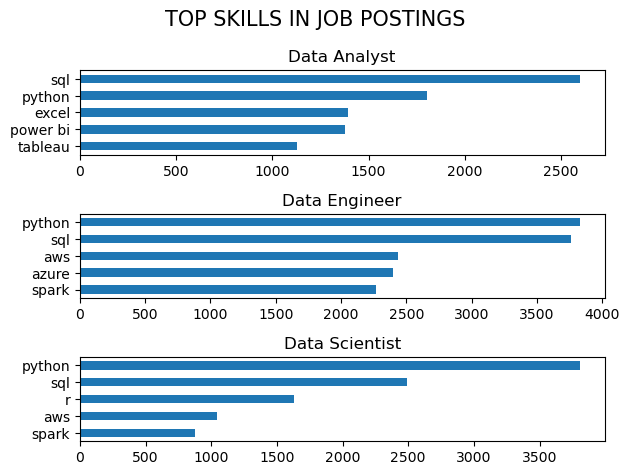

In [34]:
#Plot by subplots

fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_ES_skills_count[df_ES_skills_count['job_title_short'] == job_title].head()
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('TOP SKILLS IN JOB POSTINGS', fontsize=15)
fig.tight_layout()
plt.show()

In [37]:
# Find out the total jobs postings for each role
df_job_title_count = df_ES['job_title_short'].value_counts().reset_index(name='jobs_total')

In [41]:
# Merge the DFs to get the % of skill by roles
#Left join to get only the totals
df_skills_perc = pd.merge(df_ES_skills_count, df_job_title_count, how='left', on='job_title_short')
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total
0,python,Data Engineer,3827,6740
1,python,Data Scientist,3804,5598
2,sql,Data Engineer,3765,6740
3,sql,Data Analyst,2595,5177
4,sql,Data Scientist,2493,5598
...,...,...,...,...
1530,neo4j,Machine Learning Engineer,1,600
1531,ssrs,Senior Data Analyst,1,616
1532,ssrs,Machine Learning Engineer,1,600
1533,neo4j,Business Analyst,1,1505


In [44]:
df_skills_perc['skill_percent'] = (df_skills_perc['skill_count']/df_skills_perc['jobs_total'])*100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Engineer,3827,6740,56.780415
1,python,Data Scientist,3804,5598,67.952840
2,sql,Data Engineer,3765,6740,55.860534
3,sql,Data Analyst,2595,5177,50.125555
4,sql,Data Scientist,2493,5598,44.533762
...,...,...,...,...,...
1530,neo4j,Machine Learning Engineer,1,600,0.166667
1531,ssrs,Senior Data Analyst,1,616,0.162338
1532,ssrs,Machine Learning Engineer,1,600,0.166667
1533,neo4j,Business Analyst,1,1505,0.066445


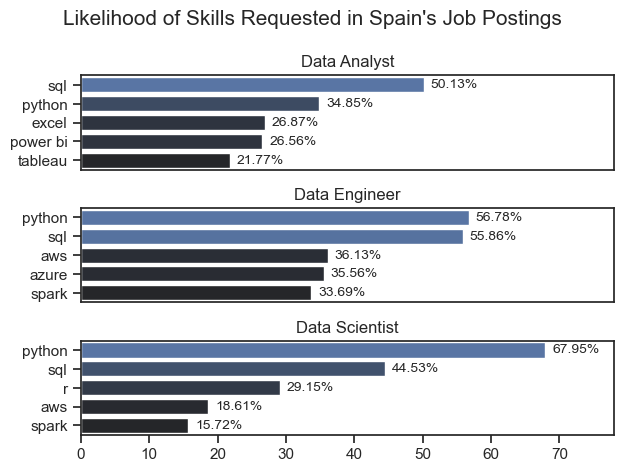

In [78]:
#Plot by subplots with the %
#Improve the chart with sns

fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head()
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().remove()
    ax[i].set_xlim(0, 78) # For all the charts have the same axis

    # Add the percent values for each chart
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.2f}%', va='center', fontsize=10)

    # remove the x titles but the last one as all have the same axis
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

fig.suptitle("Likelihood of Skills Requested in Spain's Job Postings", fontsize=15)
fig.tight_layout()
plt.show()